Output folder already exists: C:\Users\gl_pc\Desktop\data\yolov\ip3\Rat1_HM_Neurons_20260223_111321_hab_merged.raw_group0_sorting_output
Plotting...
Plot saved to: C:\Users\gl_pc\Desktop\data\yolov\ip3\Rat1_HM_Neurons_20260223_111321_hab_merged.raw_group0_sorting_output\Rat1_HM_Neurons_20260223_111321_hab_merged.raw_group0_traces_33.0s_to_38.0s.png
Recording object ready.
NumpyRecording: 128 channels - 30.0kHz - 1 segments - 122,328,426 samples - 4,077.61s (1.13 hours) 
                int16 dtype - 29.17 GiB
write_binary_recording 
engine=process - n_jobs=1 - samples_per_chunk=30,000 - chunk_memory=7.32 MiB - total_memory=7.32 MiB - chunk_duration=1.00s


c:\Users\gl_pc\.conda\envs\si_trodes\Lib\site-packages\spikeinterface\core\base.py:967: UserWarning: The extractor is not serializable to file. The provenance will not be saved.
  warnings.warn("The extractor is not serializable to file. The provenance will not be saved.")


write_binary_recording (no parallelization):   0%|          | 0/4078 [00:00<?, ?it/s]

SpikeInterface recording saved to: C:\Users\gl_pc\Desktop\data\yolov\ip3\Rat1_HM_Neurons_20260223_111321_hab_merged.raw_group0_sorting_output\si_recording


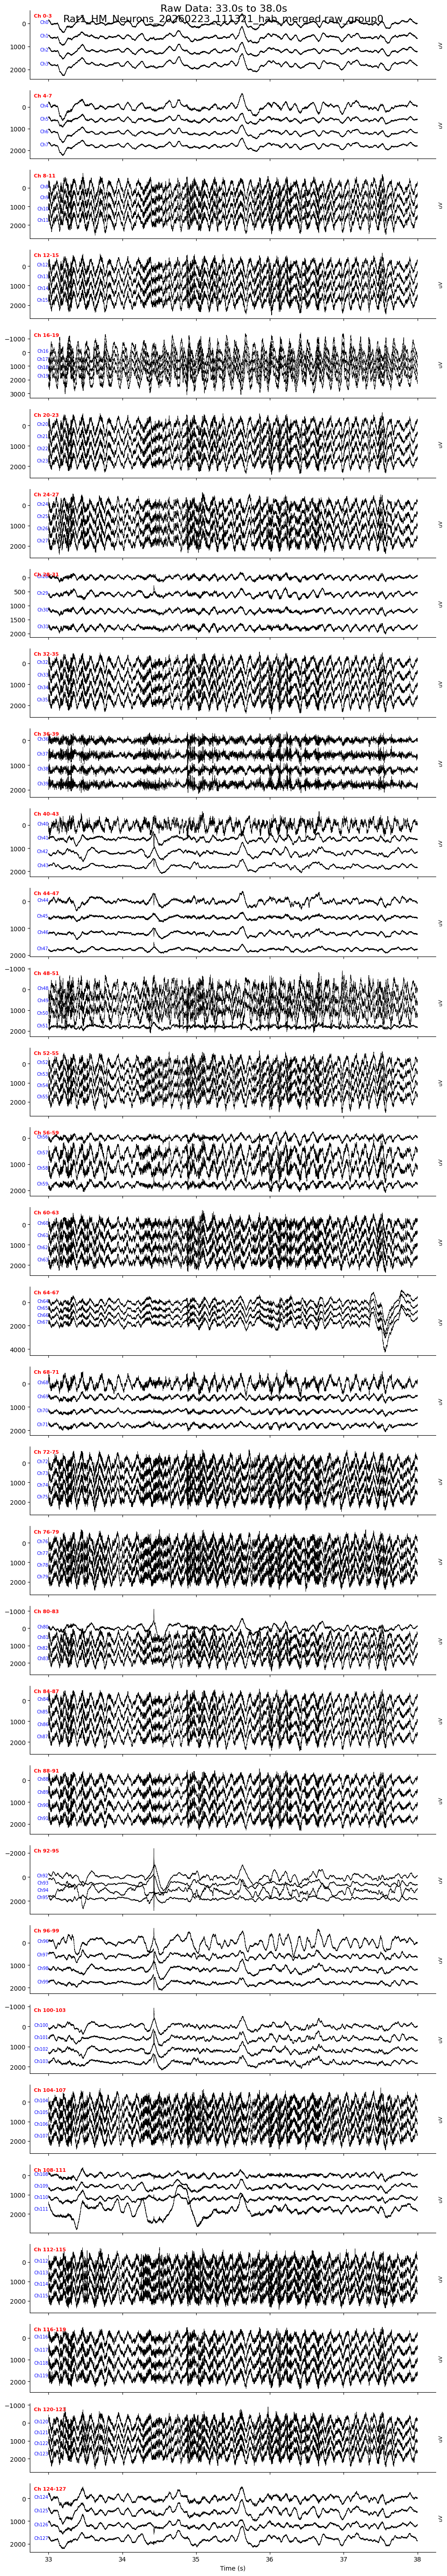

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path
import probeinterface as pi
import spikeinterface as si

# Assuming the file is in the same directory or in the python path
try:
    from readTrodesExtractedDataFile3 import readTrodesExtractedDataFile
except ImportError:
    print("Error: 'readTrodesExtractedDataFile3.py' not found. Please ensure it is in the directory.")
    raise

from probeinterface import generate_tetrode, ProbeGroup

# ---------------------------------------------------------
# 1. 设置路径与输出文件夹 (修正版)
# ---------------------------------------------------------
file_path = r"C:\Users\gl_pc\Desktop\data\yolov\ip3\Rat1_HM_Neurons_20260223_111321_hab_merged.raw/Rat1_HM_Neurons_20260223_111321_hab_merged.raw_group0.dat"

file_path_obj = Path(file_path)
file_stem = file_path_obj.stem 

# 【核心修改】
# 原来的写法: output_dir 在 .raw 文件夹里面
# 修改后的写法: .parent.parent 跳出 .raw 文件夹，存到它的旁边
# 路径变为: /Users/sachuriga/Desktop/code/spike_sorting/Rat_HM_..._output
output_parent = file_path_obj.parent.parent 
output_dir = output_parent / f"{file_stem}_sorting_output"

# 转换回 string 格式以防后续函数不兼容 Path 对象
output_dir = str(output_dir)

if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created output folder: {output_dir}")
else:
    print(f"Output folder already exists: {output_dir}")

# ---------------------------------------------------------
# 2. LOAD DATA
# ---------------------------------------------------------
# Load the file using the Trodes function
raw = readTrodesExtractedDataFile(file_path)

# Extract the voltage matrix
# Structure is: raw['data'] -> structured array -> ['voltage'] -> (Samples, Channels)
full_traces_raw = raw['data']['voltage']

# ---------------------------------------------------------
# 3. CONFIGURATION
# ---------------------------------------------------------
sampling_frequency = 30000.0
gain_to_uV = 0.195
offset_to_uV = 0.0

start_time = 33.0       
window_duration = 5.0   
offset_spacing = 600    

# Calculate frame indices
start_frame = int(start_time * sampling_frequency)
end_frame = int((start_time + window_duration) * sampling_frequency)
total_frames = full_traces_raw.shape[0]

# Check bounds
if start_frame >= total_frames:
    raise ValueError(f"Start time {start_time}s is beyond the recording duration.")
if end_frame > total_frames:
    end_frame = total_frames

# ---------------------------------------------------------
# 4. GET DATA & SCALE (FOR PLOTTING)
# ---------------------------------------------------------
traces_slice = full_traces_raw[start_frame:end_frame, :]
traces_uV = traces_slice.astype(np.float32) * gain_to_uV + offset_to_uV

num_samples = traces_uV.shape[0]
time_vector = np.linspace(start_time, start_time + (num_samples / sampling_frequency), num_samples)

# ---------------------------------------------------------
# 5. PLOTTING AND SAVING FIGURE
# ---------------------------------------------------------
rows = 32
cols = 1

fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(10, 60), sharex=True)
fig.suptitle(f'Raw Data: {start_time}s to {start_time + window_duration}s\n{file_stem}', fontsize=16)

if rows * cols > 1:
    axes_flat = axes.flatten()
else:
    axes_flat = [axes]

print("Plotting...")

for i, ax in enumerate(axes_flat):
    start_ch = i * 4
    end_ch = start_ch + 4
    group_indices = range(start_ch, end_ch)
    
    if start_ch >= traces_uV.shape[1]:
        break
    
    group_traces = traces_uV[:, group_indices]
    
    for local_idx, channel_idx in enumerate(group_indices):
        trace_to_plot = group_traces[:, local_idx] + (local_idx * offset_spacing)
        ax.plot(time_vector, trace_to_plot, color='black', linewidth=0.5)
        ax.text(start_time, np.mean(trace_to_plot), f'Ch{channel_idx}', 
                fontsize=7, color='blue', ha='right')

    ax.invert_yaxis() 
    ax.set_ylabel('uV', fontsize=8)
    ax.yaxis.set_label_position("right")
    ax.text(0.01, 0.9, f'Ch {start_ch}-{end_ch-1}', transform=ax.transAxes, 
            fontsize=8, fontweight='bold', color='red')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes_flat[-1].set_xlabel('Time (s)')

plt.tight_layout(rect=[0, 0.03, 1, 0.99])

# --- SAVE FIGURE ---
plot_filename = f"{file_stem}_traces_{start_time}s_to_{start_time+window_duration}s.png"
plot_path = os.path.join(output_dir, plot_filename)
plt.savefig(plot_path, dpi=150)
print(f"Plot saved to: {plot_path}")

# plt.show() # Optional: Comment out if running on a server without a display

# ---------------------------------------------------------
# 6. CREATE SPIKEINTERFACE RECORDING
# ---------------------------------------------------------
rec = si.NumpyRecording(
    traces_list=[full_traces_raw], 
    sampling_frequency=sampling_frequency
)

rec.set_channel_gains(gain_to_uV)
rec.set_channel_offsets(offset_to_uV)

# ---------------------------------------------------------
# 7. ATTACH PROBE & SAVE RECORDING OBJECT
# ---------------------------------------------------------
num_channels = full_traces_raw.shape[1]
probe = pi.generate_linear_probe(num_elec=num_channels, ypitch=20)
probe.set_device_channel_indices(np.arange(num_channels))
rec = rec.set_probe(probe)

print("Recording object ready.")
print(rec)

# --- SAVE RECORDING OBJECT ---
# This saves the SpikeInterface object to the output folder so it can be loaded later
# (e.g. using si.load_extractor())
si_output_path = os.path.join(output_dir, "si_recording")

if os.path.exists(si_output_path):
    import shutil
    shutil.rmtree(si_output_path) # Remove existing to overwrite

rec.save(folder=si_output_path)
print(f"SpikeInterface recording saved to: {si_output_path}")

Visualizing Probe Geometry...
Probe geometry image saved to: C:\Users\gl_pc\Desktop\data\yolov\ip3\Rat1_HM_Neurons_20260223_111321_hab_merged.raw_group0_sorting_output\Rat1_HM_Neurons_20260223_111321_hab_merged.raw_group0_probe_geometry.png
Probe attached. Total Groups: 32
Preprocessing...


PermissionError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\gl_pc\\Desktop\\data\\yolov\\ip3\\Rat1_HM_Neurons_20260223_111321_hab_merged.raw_group0_sorting_output\\processed_binary\\traces_cached_seg0.raw'

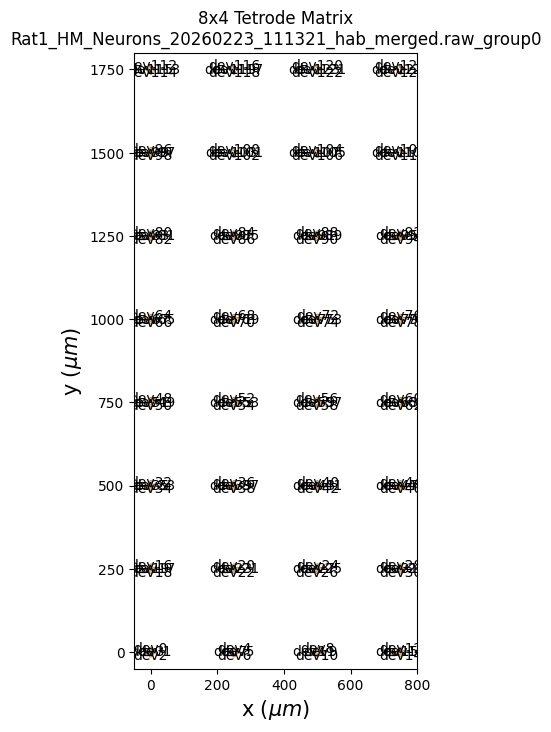

In [6]:
import numpy as np
import probeinterface as pi
import spikeinterface.full as si
import matplotlib.pyplot as plt
from probeinterface.plotting import plot_probe
import spikeinterface.preprocessing as spre
import os
import shutil
from pathlib import Path

# Assuming the file is in the same directory or in the python path
try:
    from readTrodesExtractedDataFile3 import readTrodesExtractedDataFile
except ImportError:
    # 仅为了防止报错，实际运行时请确保文件存在
    pass

# ---------------------------------------------------------
# 6. 自定义 PROBE GEOMETRY (8x4 Tetrode Grid)
# ---------------------------------------------------------

# 参数设定
num_tetrodes = 32
rows = 8
cols = 4
inter_tetrode_spacing = 250.0 

# 定义菱形 (Diamond) 的偏移量
diamond_offsets = np.array([
    [0, 10],   # Ch1 (Top)
    [10, 0],   # Ch2 (Right)
    [0, -10],  # Ch3 (Bottom)
    [-10, 0]   # Ch4 (Left)
])

all_positions = []
all_device_indices = []
group_ids = []

tetrode_idx = 0

for r in range(rows):
    for c in range(cols):
        x_center = c * inter_tetrode_spacing
        y_center = r * inter_tetrode_spacing
        
        for local_idx in range(4):
            pos = [x_center + diamond_offsets[local_idx, 0], 
                   y_center + diamond_offsets[local_idx, 1]]
            all_positions.append(pos)
            all_device_indices.append(tetrode_idx * 4 + local_idx)
            group_ids.append(tetrode_idx)
            
        tetrode_idx += 1

# import numpy as np
# from probeinterface import ProbeGroup, generate_tetrode

# inter_tetrode_spacing = 250.0 
# rows = 4  # Assuming you have defined rows
# cols = 4  # Assuming you have defined cols

# # Initialize an empty ProbeGroup to hold all tetrodes
# probegroup = ProbeGroup()
# tetrode_idx = 0

# for r in range(rows):
#     for c in range(cols):
#         # 1. Generate the base tetrode geometry
#         tetrode = generate_tetrode()
        
#         # 2. Calculate its grid position and move it
#         x_center = c * inter_tetrode_spacing
#         y_center = r * inter_tetrode_spacing
#         tetrode.move([x_center, y_center])
        
#         # 3. Assign the correct continuous channel indices (e.g., 0-3, 4-7...)
#         tetrode.set_device_channel_indices(np.arange(4) + tetrode_idx * 4)
        
#         # 4. Add the finished tetrode to the group
#         probegroup.add_probe(tetrode)
        
        # tetrode_idx += 1

# 5. Attach the completed probe group to your recording
# Using group_mode='by_probe' automatically takes care of assigning unique group IDs!
# recording = rec.set_probegroup(probegroup, group_mode='by_probe')

#all_positions = np.array(all_positions)
#all_device_indices = np.array(all_device_indices)

# 创建 Probe 对象
probe = pi.Probe(ndim=2, si_units='um')
probe.set_contacts(positions=all_positions, shapes='circle', shape_params={'radius': 5})
probe.set_device_channel_indices(all_device_indices)

# 可视化并保存 Probe 形状
print("Visualizing Probe Geometry...")
fig_probe, ax_probe = plt.subplots(figsize=(5, 8))
plot_probe(probe, ax=ax_probe, with_device_index=True)
ax_probe.set_title(f"8x4 Tetrode Matrix\n{file_stem}")

# --- 保存 Probe 图片 ---
probe_img_path = os.path.join(output_dir, f"{file_stem}_probe_geometry.png")
plt.savefig(probe_img_path, dpi=150)
print(f"Probe geometry image saved to: {probe_img_path}")
# plt.show() # 如果在服务器运行建议注释掉

# 将 Probe 绑定到 Recording
rec = rec.set_probe(probe)
rec.set_property("group", group_ids)
print(f"Probe attached. Total Groups: {len(np.unique(group_ids))}")

# ---------------------------------------------------------
# 7. 运行 SPIKE SORTING (按 GROUP)
# ---------------------------------------------------------
print("Preprocessing...")


# 共模参考
rec_processed = spre.common_reference(rec, reference='global', operator='median')
#recording_preprocessed: si.BaseRecording = spre.whiten(rec_processed)


# --- 定义预处理数据的保存路径 ---
# 在 output_dir 下创建一个 processed_binary 子文件夹
processed_folder = os.path.join(output_dir, 'processed_binary')

# 如果文件夹存在，SpikeInterface 可能会报错，所以可以选择先删除，或者依靠 overwrite=True
if os.path.exists(processed_folder):
    shutil.rmtree(processed_folder)

# 保存预处理后的数据 (这是 Sorting 的实际输入)
rec_saved = rec_processed.save(
    folder=processed_folder, 
    format='binary', 
    overwrite=True, 
    n_jobs=1, 
    chunk_duration="1s",
    progress_bar=True
)
# ---------------------------------------------------------
# 7. 运行 SPIKE SORTING (修正 run_sorter 部分)
# ---------------------------------------------------------

In [ ]:
# ... (Step 7 开头的滤波和预处理保存部分保持不变) ...
import os

# Create a temporary directory that actually exists on Windows
win_temp = os.path.join(os.getcwd(), "ms4_temp")
if not os.path.exists(win_temp):
    os.makedirs(win_temp)

# Set the environment variable MountainSort4 is looking for
os.environ['TEMPDIR'] = win_temp
# # Sorter 参数
sorter_name = 'mountainsort5' 
para = si.get_default_sorter_params('mountainsort5')
para['detect_sign'] = 0
#para['detect_threshold'] = 3
para['filter'] = False
para['scheme'] = '2'
#para['whiten'] = False


# sorter_name = 'spykingcircus' 
# para = si.get_default_sorter_params(sorter_name)
# para['detect_sign'] = 0

# whitened_recording = spre.whiten(
#     rec_saved, 
#     mode="local", 
#     radius_um=50.0, 
#     int_scale=200
# )


print("Saving preprocessed data to disk...")
if sorter_name not in si.available_sorters():
    print(f"Warning: {sorter_name} not found. Available: {si.available_sorters()}")
else:
    print(f"Starting sorting using {sorter_name}...")
    
    # 彻底清理旧的 sorting 工作目录，防止文件冲突
    sorter_work_folder = os.path.join(output_dir, 'sorting_work_folder')
    if os.path.exists(sorter_work_folder):
        shutil.rmtree(sorter_work_folder)
    
    # 运行 Sorter
    # 注意：在 run_sorter_by_property 中，不需要再传 remove_existing_folder=True 给 **para
    # 因为我们已经在上面手动清理过主文件夹了，这样更稳妥。
    sorting = si.run_sorter_by_property(
        sorter_name=sorter_name,
        recording=rec_saved,
        grouping_property='group',
        folder=sorter_work_folder,
        verbose=True,
        # 移除 remove_existing_folder，防止子进程互相打架
        **para
    )

    print("Sorting complete!")
    print(sorting)
    
    final_output_folder = os.path.join(output_dir, 'final_sorting_result')
    if os.path.exists(final_output_folder):
        shutil.rmtree(final_output_folder)
        
    sorting.save(folder=final_output_folder)
    print(f"Final sorting object saved to: {final_output_folder}")

Saving preprocessed data to disk...
Starting sorting using mountainsort5...
write_binary_recording 
engine=process - n_jobs=1 - samples_per_chunk=30,000 - chunk_memory=234.38 KiB - total_memory=234.38 KiB - chunk_duration=1.00s


c:\Users\gl_pc\.conda\envs\si_trodes\Lib\site-packages\spikeinterface\sorters\external\mountainsort5.py:149: UserWarning: Not whitening (MountainSort5 expects whitened data)
  warn("Not whitening (MountainSort5 expects whitened data)")


write_binary_recording (no parallelization):   0%|          | 0/4078 [00:00<?, ?it/s]

Using training recording of duration 300 sec with the sampling mode uniform
*** MS5 Elapsed time for SCHEME2 get_sampled_recording_for_training: 0.056 seconds ***
Running phase 1 sorting
Number of channels: 4
Number of timepoints: 9000000
Sampling frequency: 30000.0 Hz
Channel 0: [ 0. 10.]
Channel 1: [10.  0.]
Channel 2: [  0. -10.]
Channel 3: [-10.   0.]
Loading traces
*** MS5 Elapsed time for load_traces: 0.000 seconds ***
Detecting spikes

Adjacency for detect spikes with channel radius 200
[[0, 1, 2, 3], [0, 1, 2, 3], [0, 1, 2, 3], [0, 1, 2, 3]]

m = 0 (nbhd size: 4)
m = 1 (nbhd size: 4)
m = 2 (nbhd size: 4)
m = 3 (nbhd size: 4)
Detected 204281 spikes
*** MS5 Elapsed time for detect_spikes: 80.345 seconds ***
Removing duplicate times
*** MS5 Elapsed time for remove_duplicate_times: 0.002 seconds ***
Extracting 203945 snippets
*** MS5 Elapsed time for extract_snippets: 0.592 seconds ***
Computing PCA features with npca=12
*** MS5 Elapsed time for compute_pca_features: 0.067 seconds 

c:\Users\gl_pc\.conda\envs\si_trodes\Lib\site-packages\spikeinterface\sorters\external\mountainsort5.py:149: UserWarning: Not whitening (MountainSort5 expects whitened data)
  warn("Not whitening (MountainSort5 expects whitened data)")


write_binary_recording (no parallelization):   0%|          | 0/4078 [00:00<?, ?it/s]

Using training recording of duration 300 sec with the sampling mode uniform
*** MS5 Elapsed time for SCHEME2 get_sampled_recording_for_training: 0.057 seconds ***
Running phase 1 sorting
Number of channels: 4
Number of timepoints: 9000000
Sampling frequency: 30000.0 Hz
Channel 0: [250.  10.]
Channel 1: [260.   0.]
Channel 2: [250. -10.]
Channel 3: [240.   0.]
Loading traces
*** MS5 Elapsed time for load_traces: 0.000 seconds ***
Detecting spikes

Adjacency for detect spikes with channel radius 200
[[0, 1, 2, 3], [0, 1, 2, 3], [0, 1, 2, 3], [0, 1, 2, 3]]

m = 0 (nbhd size: 4)
m = 1 (nbhd size: 4)
m = 2 (nbhd size: 4)
m = 3 (nbhd size: 4)
Detected 262318 spikes
*** MS5 Elapsed time for detect_spikes: 109.371 seconds ***
Removing duplicate times
*** MS5 Elapsed time for remove_duplicate_times: 0.002 seconds ***
Extracting 262127 snippets
*** MS5 Elapsed time for extract_snippets: 0.788 seconds ***
Computing PCA features with npca=12
*** MS5 Elapsed time for compute_pca_features: 0.087 sec

SpikeSortingError: Spike sorting error trace:
Traceback (most recent call last):
  File "c:\Users\gl_pc\.conda\envs\si_trodes\Lib\site-packages\spikeinterface\sorters\basesorter.py", line 270, in run_from_folder
    SorterClass._run_from_folder(sorter_output_folder, sorter_params, verbose)
  File "c:\Users\gl_pc\.conda\envs\si_trodes\Lib\site-packages\spikeinterface\sorters\external\mountainsort5.py", line 194, in _run_from_folder
    sorting = ms5.sorting_scheme2(recording=recording_cached, sorting_parameters=scheme2_sorting_parameters)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\gl_pc\.conda\envs\si_trodes\Lib\site-packages\mountainsort5\schemes\sorting_scheme2.py", line 88, in sorting_scheme2
    sorting1 = sorting_scheme1(
               ^^^^^^^^^^^^^^^^
  File "c:\Users\gl_pc\.conda\envs\si_trodes\Lib\site-packages\mountainsort5\schemes\sorting_scheme1.py", line 136, in sorting_scheme1
    offsets = 

In [ ]:
import os
import shutil
import spikeinterface.full as si

# ---------------------------------------------------------
# 8. 创建 SORTING ANALYZER (新版核心对象)
# ---------------------------------------------------------
print("Initializing SortingAnalyzer (New API)...")

# 定义 Analyzer 在 output_dir 内部的保存路径
analyzer_folder = os.path.join(output_dir, "sorting_analyzer")

# 如果之前跑过，先清理掉，防止缓存冲突
if os.path.exists(analyzer_folder):
    shutil.rmtree(analyzer_folder)

# 1. 创建 Analyzer 对象
# sparse=True 会利用 Probe 的几何信息 (Tetrode group)，只在相关通道上提取波形
analyzer = si.create_sorting_analyzer(
    sorting=sorting,
    recording=rec_saved,
    format="binary_folder",
    folder=analyzer_folder, 
    overwrite=True,
    sparse=True 
)

# ---------------------------------------------------------
# 9. 计算波形、PCA 和 指标 (链式计算)
# ---------------------------------------------------------
print("Computing necessary features...")

# 设置并行核心数，加快计算速度
job_kwargs = {'n_jobs': 4, 'chunk_duration': '1s', 'progress_bar': True}

# 2. 选择随机 Spikes (用于计算模板)
analyzer.compute("random_spikes", method="uniform", max_spikes_per_unit=500, **job_kwargs)

# 3. 计算波形 (Waveforms)
# 这是最耗时的一步，利用多核计算
print("Extracting waveforms...")
analyzer.compute("waveforms", ms_before=1.0, ms_after=2.0, **job_kwargs)

# 4. 计算模板 (Templates - 平均波形)
analyzer.compute("templates", **job_kwargs)

# 5. 计算噪音水平 (Noise levels)
analyzer.compute("noise_levels", **job_kwargs)

# 6. 计算主成分 (PCA)
# mode='by_channel_local' 对于 Tetrode/Probe 来说是必须的
print("Computing PCA...")
analyzer.compute("principal_components", n_components=3, mode='by_channel_local', **job_kwargs)

# 7. (可选) 计算质量指标
print("Computing Quality Metrics...")
analyzer.compute("quality_metrics", metric_names=['snr', 'isi_violation', 'firing_rate'], **job_kwargs)

print(analyzer)

# ---------------------------------------------------------
# 10. 导出到 PHY
# ---------------------------------------------------------
# 定义 Phy 文件夹在 output_dir 内部
phy_output_folder = os.path.join(output_dir, "phy_export")
print(f"Exporting results to Phy: {phy_output_folder}")

if os.path.exists(phy_output_folder):
    shutil.rmtree(phy_output_folder)

# 导出
si.export_to_phy(
    sorting_analyzer=analyzer,
    output_folder=phy_output_folder,
    compute_pc_features=True, # 因为我们已经在上面 compute("principal_components") 了
    compute_amplitudes=True,
    remove_if_exists=True,
    copy_binary=False, # False = 引用之前保存的 binary 文件 (节省空间); True = 复制一份新的
)

print("---------------------------------------------------------")
print("Done! All processing finished.")
print(f"To open Phy, run this command in your terminal:")
print(f"phy template-gui {phy_output_folder}/params.py")
print("---------------------------------------------------------")

Initializing SortingAnalyzer (New API)...


estimate_sparsity (no parallelization):   0%|          | 0/4078 [00:00<?, ?it/s]

c:\Users\gl_pc\.conda\envs\si_trodes\Lib\site-packages\spikeinterface\core\basesorting.py:380: UserWarning: The registered recording will not be persistent on disk, but only available in memory
  warnings.warn("The registered recording will not be persistent on disk, but only available in memory")


Computing necessary features...
Extracting waveforms...


compute_waveforms (workers: 4 processes):   0%|          | 0/4078 [00:00<?, ?it/s]

...

Projecting waveforms:   0%|          | 0/174 [00:00<?, ?it/s]

Computing Quality Metrics...
SortingAnalyzer: 128 channels - 174 units - 1 segments - binary_folder - sparse - has recording
Loaded 6 extensions: random_spikes, waveforms, templates, noise_levels, principal_components, quality_metrics
Exporting results to Phy: C:\Users\gl_pc\Desktop\data\yolov\ip3\Rat1_HM_Neurons_20260223_111321_hab_merged.raw_group0_sorting_output\phy_export


spike_amplitudes (no parallelization):   0%|          | 0/4078 [00:00<?, ?it/s]

extract PCs (no parallelization):   0%|          | 0/4078 [00:00<?, ?it/s]

Run:
phy template-gui  C:\Users\gl_pc\Desktop\data\yolov\ip3\Rat1_HM_Neurons_20260223_111321_hab_merged.raw_group0_sorting_output\phy_export\params.py
---------------------------------------------------------
Done! All processing finished.
To open Phy, run this command in your terminal:
phy template-gui C:\Users\gl_pc\Desktop\data\yolov\ip3\Rat1_HM_Neurons_20260223_111321_hab_merged.raw_group0_sorting_output\phy_export/params.py
---------------------------------------------------------


In [ ]:
import spikeinterface.full as si
import os
import spikeinterface.widgets as sw
import os

# Replace 'YOUR_API_KEY_HERE' with the key you got from the website
os.environ["KACHERY_API_KEY"] = "wYcpkUeJcurwErAVrj6ASX42nGDPMYrz"
os.environ["KACHERY_CLOUD_DIR"] = "kachery_storage"

# Define the path where you saved it (same as your previous script)
output_dir = r"C:\Users\gl_pc\Desktop\data\yolov\ip3\Rat1_HM_Neurons_20260223_111321_hab_merged.raw_group0_sorting_output" # Update this to your actual path
analyzer_folder = os.path.join(output_dir, "sorting_analyzer")

# Load the analyzer
analyzer = si.load_sorting_analyzer(analyzer_folder)

analyzer.compute('correlograms')
#analyzer.compute('correlograms',window_ms=20,bin_ms=1)

#w_ts = sw.plot_traces(recording=rec_saved, backend="sortingview")
analyzer.compute('unit_locations')
w_ss = sw.plot_sorting_summary(sorting_analyzer=analyzer, curation=True, backend="sortingview",displayed_unit_properties=['group'])

Computing sha1 of C:\Users\gl_pc\AppData\Local\Temp\tmpfzrsbh20/file.dat
https://figurl.org/f?v=npm://@fi-sci/figurl-sortingview@12/dist&d=kachery:default:sha1:6b39a6bedccbec9db1139366a8c218078d990ef0


In [ ]:
from neuroconv.datainterfaces import PhySortingInterface
from datetime import datetime
from zoneinfo import ZoneInfo

folder_path = r"C:\phy_export"
nwb_output_path = r"C:\Users\gl_pc\Desktop\data\yolov\op3/my_sorting_data.nwb"

# 1. Initialize the interface
interface = PhySortingInterface(folder_path=folder_path, verbose=False)

# 2. Extract metadata (optional: customize this dict to add subject info)
metadata = interface.get_metadata()
metadata["NWBFile"]["session_start_time"] = datetime.now(ZoneInfo("US/Pacific"))

# 3. Run conversion
interface.run_conversion(nwbfile_path=nwb_output_path, metadata=metadata)
print(f"Converted Phy data to {nwb_output_path}")

Converted Phy data to C:\Users\gl_pc\Desktop\data\yolov\op3/my_sorting_data.nwb


In [ ]:
from pynwb import NWBHDF5IO

nwb_file_path = r"C:\Users\gl_pc\Desktop\data\yolov\op3/my_sorting_data.nwb"

with NWBHDF5IO(nwb_file_path, "r") as io:
    nwbfile = io.read()
    
    # The spike data is stored in the "units" table
    units = nwbfile.units
    
    # Convert to a Pandas DataFrame for easy viewing
    units_df = units.to_dataframe()
    print(units_df.head())
    
    # Access spike times for the first unit (index 0)
    spike_times = units['spike_times'][0]
    print(f"First unit has {len(spike_times)} spikes")

                                          spike_times unit_name  \
id                                                                
0   [0.0, 0.0015333333333333334, 0.011, 0.01266666...         0   
1   [0.007733333333333333, 0.016366666666666668, 0...         1   
2   [0.003533333333333333, 0.006, 0.01003333333333...         2   
3   [0.0027, 0.0044, 0.005166666666666667, 0.00686...         3   
4   [0.032466666666666665, 0.0342, 0.0359, 0.0375,...         4   

    isi_violations_ratio        amp  isi_violations_count  group  sh   ch  \
id                                                                          
0               1.180777  35.328152               11892.0      0   0    0   
1               4.375769  72.331757               13373.0      0   0  127   
2               1.320506  45.690453               17506.0      0   0   94   
3               2.091651  59.233566               17083.0      0   0   96   
4               1.593643  39.401299               23284.0      1   0

In [ ]:
godd_df = units_df[units_df['quality']=='good']
spike_times=units_df[units_df['quality']=='good']['spike_times'].reset_index(drop=True)
spike_times

0     [0.0008, 0.0033, 0.0525, 0.06523333333333334, ...
1     [0.0, 0.009966666666666667, 1.2991, 9.6512, 9....
2     [9.068966666666666, 9.175566666666667, 9.4294,...
3     [1.2985666666666666, 9.0684, 9.1749, 9.4287333...
4     [9.5166, 9.697533333333332, 10.543533333333333...
5     [0.011666666666666667, 0.04133333333333333, 0....
6     [1.7238, 3.0501666666666667, 3.580066666666666...
7     [18.031633333333332, 54.98343333333333, 54.988...
8     [0.028766666666666666, 0.25493333333333335, 0....
9     [0.17566666666666667, 0.2689, 0.2741, 0.3586, ...
10    [3.3333333333333335e-05, 0.0017, 0.0051, 0.030...
11    [0.0005666666666666667, 6.936166666666667, 24....
12    [0.18086666666666668, 48.110033333333334, 48.1...
13    [0.13096666666666668, 61.227533333333334, 61.2...
14    [3.3868, 25.064266666666665, 25.0717, 25.15913...
15    [3.3333333333333335e-05, 20.8397, 669.84746666...
16    [4.610333333333333, 4.6164, 4.8245, 5.09723333...
17    [0.5817666666666667, 0.6805666666666667, 0

In [ ]:
import pandas as pd

def load_coords_pandas(csv_path):
    """
    Loads coordinate data from a CSV file into a Pandas DataFrame.
    """
    df = pd.read_csv(csv_path)
    return df
# --- Usage ---
file_path = r'C:\Users\gl_pc\Desktop\data\yolov\op3/20260223_Rat1_Coordinates_Full.csv'
file_path_secounds = r'C:\Users\gl_pc\Desktop\data\yolov\op3/stitched_framewise_seconds.csv'
# --- Usage ---
df = load_coords_pandas(file_path)
df1 = load_coords_pandas(file_path_secounds)

merged_df = pd.concat([df1, df], axis=1)
positions = merged_df[['Seconds From Creation', 'Rat_X', 'Rat_Y']]
pos = positions[positions['Seconds From Creation']>0].reset_index(drop=True)
pos

,Seconds From Creation,Rat_X,Rat_Y
0,0.030540,NaN,NaN
1,0.064749,NaN,NaN
2,0.097922,NaN,NaN
3,0.131164,NaN,NaN
4,0.164007,NaN,NaN
...,...,...,...
122737,4090.522236,1077.0,307.0
122738,4090.556367,1077.0,307.0
122739,4090.588241,1077.0,307.0
122740,4090.621755,1077.0,307.0


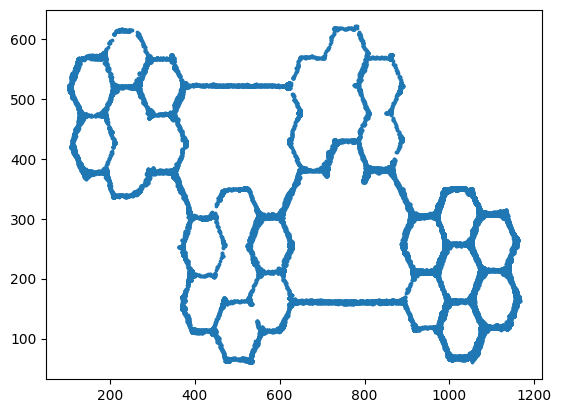

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(pos['Rat_X'],pos['Rat_Y'],s=3)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# --- 1. Setup Output Folder ---
# Define the folder name
output_folder = "unit_firing_plots"

# Create the folder if it doesn't exist
os.makedirs(output_folder, exist_ok=True)

# --- 2. Loop Through Units ---
unit_id = 0

for unit_spikes in spike_times:
    unit_id += 1
    
    # Find the position of the rat at each spike time
    # Assumes pos['Seconds From Creation'] is sorted
    spike_indices = np.searchsorted(pos['Seconds From Creation'], unit_spikes)

    # Filter out spikes that happened before/after the tracking data
    # (Indices of 0 or len(pos) mean the spike time was outside the tracking range)
    valid_mask = (spike_indices > 0) & (spike_indices < len(pos))
    spike_indices = spike_indices[valid_mask]

    # Get X and Y for those valid spikes
    spike_x = pos.iloc[spike_indices]['Rat_X']
    spike_y = pos.iloc[spike_indices]['Rat_Y']

    # --- 3. Plot ---
    plt.figure(figsize=(6, 6))

    # Plot the full path (grey background)
    plt.plot(pos['Rat_X'], pos['Rat_Y'], color='lightgrey', alpha=0.5, label='Trajectory')

    # Plot the spikes (red dots)
    plt.scatter(spike_x, spike_y, color='red', s=2, label=f'Unit {unit_id} Spikes')

    plt.title(f'Spatial Firing: Unit {unit_id}')
    plt.axis('equal')
    
    # *** INVERT Y AXIS HERE ***
    plt.gca().invert_yaxis()
    
    plt.legend(loc='upper right')
    
    # --- 4. Save and Close ---
    # Construct the filename
    file_name = f"Unit_{unit_id:03d}_spatial_firing.png" # e.g., Unit_001_spatial_firing.png
    save_path = os.path.join(output_folder, file_name)
    
    # Save the figure
    plt.savefig(save_path, dpi=150) # dpi=150 makes it higher quality
    
    # Close the figure to free up memory (Crucial for loops!)
    plt.close()

print(f"Done! {unit_id} images saved to the folder: {output_folder}")

Done! 37 images saved to the folder: unit_firing_plots


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# --- 1. Setup Output Folder ---
# Define the folder name
output_folder = "unit_firing_plots"

# Create the folder if it doesn't exist
os.makedirs(output_folder, exist_ok=True)

# --- 2. Loop Through Units ---
unit_id = 0

for unit_spikes in spike_times:
    unit_id += 1
    
    # Find the position of the rat at each spike time
    # Assumes pos['Seconds From Creation'] is sorted
    spike_indices = np.searchsorted(pos['Seconds From Creation'], unit_spikes)

    # Filter out spikes that happened before/after the tracking data
    # (Indices of 0 or len(pos) mean the spike time was outside the tracking range)
    valid_mask = (spike_indices > 0) & (spike_indices < len(pos))
    spike_indices = spike_indices[valid_mask]

    # Get X and Y for those valid spikes
    spike_x = pos.iloc[spike_indices]['Rat_X']
    spike_y = pos.iloc[spike_indices]['Rat_Y']

    # --- 3. Plot ---
    plt.figure(figsize=(6, 6))

    # Plot the full path (grey background)
    plt.plot(pos['Rat_X'], pos['Rat_Y'], color='lightgrey', alpha=0.5, label='Trajectory')

    # Plot the spikes (red dots)
    plt.scatter(spike_x, spike_y, color='red', s=2, label=f'Unit {unit_id} Spikes')

    plt.title(f'Spatial Firing: Unit {unit_id}')
    plt.axis('equal')
    
    # *** INVERT Y AXIS HERE ***
    plt.gca().invert_yaxis()
    
    plt.legend(loc='upper right')
    
    # --- 4. Save and Close ---
    # Construct the filename
    file_name = f"Unit_{unit_id:03d}_spatial_firing.png" # e.g., Unit_001_spatial_firing.png
    save_path = os.path.join(output_folder, file_name)
    
    # Save the figure
    plt.savefig(save_path, dpi=150) # dpi=150 makes it higher quality
    
    # Close the figure to free up memory (Crucial for loops!)
    plt.close()

print(f"Done! {unit_id} images saved to the folder: {output_folder}")

Done! 15 images saved to the folder: unit_firing_plots


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# --- 1. Setup Output Folder ---
# Define the folder name
output_folder = "unit_firing_plots"

# Create the folder if it doesn't exist
os.makedirs(output_folder, exist_ok=True)

# --- 2. Loop Through Units ---
unit_id = 0

for unit_spikes in spike_times:
    unit_id += 1
    
    # Find the position of the rat at each spike time
    # Assumes pos['Seconds From Creation'] is sorted
    spike_indices = np.searchsorted(pos['Seconds From Creation'], unit_spikes)

    # Filter out spikes that happened before/after the tracking data
    # (Indices of 0 or len(pos) mean the spike time was outside the tracking range)
    valid_mask = (spike_indices > 0) & (spike_indices < len(pos))
    spike_indices = spike_indices[valid_mask]

    # Get X and Y for those valid spikes
    spike_x = pos.iloc[spike_indices]['Rat_X']
    spike_y = pos.iloc[spike_indices]['Rat_Y']

    # --- 3. Plot ---
    plt.figure(figsize=(6, 6))

    # Plot the full path (grey background)
    plt.plot(pos['Rat_X'], pos['Rat_Y'], color='lightgrey', alpha=0.5, label='Trajectory')

    # Plot the spikes (red dots)
    plt.scatter(spike_x, spike_y, color='red', s=2, label=f'Unit {unit_id} Spikes')

    plt.title(f'Spatial Firing: Unit {unit_id}')
    plt.axis('equal')
    
    # *** INVERT Y AXIS HERE ***
    plt.gca().invert_yaxis()
    
    plt.legend(loc='upper right')
    
    # --- 4. Save and Close ---
    # Construct the filename
    file_name = f"Unit_{unit_id:03d}_spatial_firing.png" # e.g., Unit_001_spatial_firing.png
    save_path = os.path.join(output_folder, file_name)
    
    # Save the figure
    plt.savefig(save_path, dpi=150) # dpi=150 makes it higher quality
    
    # Close the figure to free up memory (Crucial for loops!)
    plt.close()

print(f"Done! {unit_id} images saved to the folder: {output_folder}")

Done! 37 images saved to the folder: unit_firing_plots


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from scipy.ndimage import gaussian_filter

# --- 1. Setup Output Folder ---
output_folder = "unit_rate_maps"
os.makedirs(output_folder, exist_ok=True)

# --- 2. Calculate Speed ---
# Calculate differences in position and time
dx = np.diff(pos['Rat_X'], prepend=pos['Rat_X'].iloc[0])
dy = np.diff(pos['Rat_Y'], prepend=pos['Rat_Y'].iloc[0])
dt = np.diff(pos['Seconds From Creation'], prepend=pos['Seconds From Creation'].iloc[0])

# Handle potential division by zero if dt is 0 (though rare in tracking data)
dt[dt <= 0] = 1e-9 

# Calculate speed (distance / time)
speed = np.sqrt(dx**2 + dy**2) / dt
pos['Speed'] = speed

# --- 3. Define Parameters for Mapping ---
# Spatial binning parameters
bin_size = 5  # Size of bins (e.g., 5cm or 5 pixels)
x_min, x_max = pos['Rat_X'].min(), pos['Rat_X'].max()
y_min, y_max = pos['Rat_Y'].min(), pos['Rat_Y'].max()

x_bins = np.arange(x_min, x_max + bin_size, bin_size)
y_bins = np.arange(y_min, y_max + bin_size, bin_size)

# Smoothing parameter (standard deviation of the Gaussian kernel)
sigma = 1.5 

# SPEED THRESHOLD (as requested)
speed_threshold = 10 # Units depend on your data (e.g., cm/s or px/s)

# --- 4. Calculate Occupancy Map ---
# Filter position data for speed > 0.05
# We use the time duration (dt) as the weight to get total time in seconds per bin
running_mask = pos['Speed'] > speed_threshold
running_pos = pos[running_mask]
running_dt = dt[running_mask]

occupancy_map, _, _ = np.histogram2d(
    running_pos['Rat_X'], 
    running_pos['Rat_Y'], 
    bins=[x_bins, y_bins], 
    weights=running_dt
)

# Avoid division by zero later (set 0 occupancy to NaN or a dummy value)
# We will treat bins with 0 occupancy as unvisited
occupancy_map[occupancy_map == 0] = np.nan

# --- 5. Loop Through Units and Plot Rate Maps ---
unit_id = 0

for unit_spikes in spike_times:
    unit_id += 1
    
    # --- A. Find Spike Positions and Speeds ---
    spike_indices = np.searchsorted(pos['Seconds From Creation'], unit_spikes)
    
    # Filter valid indices (within recording bounds)
    valid_idx_mask = (spike_indices > 0) & (spike_indices < len(pos))
    spike_indices = spike_indices[valid_idx_mask]
    
    # Get X, Y, and Speed for every spike
    current_spike_x = pos.iloc[spike_indices]['Rat_X'].values
    current_spike_y = pos.iloc[spike_indices]['Rat_Y'].values
    current_spike_speed = pos.iloc[spike_indices]['Speed'].values
    
    # --- B. Filter Spikes by Speed Threshold ---
    # Only keep spikes that happened while the rat was moving > 0.05
    valid_speed_mask = current_spike_speed > speed_threshold
    filtered_spike_x = current_spike_x[valid_speed_mask]
    filtered_spike_y = current_spike_y[valid_speed_mask]
    
    # --- C. Calculate Spike Map ---
    # Count number of spikes in each bin
    spike_map, _, _ = np.histogram2d(
        filtered_spike_x, 
        filtered_spike_y, 
        bins=[x_bins, y_bins]
    )
    
    # --- D. Calculate Rate Map (Hz) ---
    # Rate = Spikes / Time (Occupancy)
    raw_rate_map = spike_map / occupancy_map
    
    # --- E. Smooth the Map ---
    # We use nan_to_num to handle the NaNs (unvisited bins) during smoothing,
    # usually, we smooth the spike map and occupancy map separately or interpolate NaNs.
    # For simplicity, here is the standard Gaussian smooth on the valid rate map:
    
    # 1. Create a mask of valid pixels
    valid_pixels = ~np.isnan(raw_rate_map)
    # 2. Replace NaNs with 0 for smoothing
    rate_map_filled = np.nan_to_num(raw_rate_map)
    # 3. Smooth
    smoothed_rate_map = gaussian_filter(rate_map_filled, sigma=sigma)
    # 4. Re-apply NaN to unvisited areas (optional, for visual clarity)
    smoothed_rate_map[~valid_pixels] = np.nan

    # --- F. Plot ---
    plt.figure(figsize=(7, 6))
    
    # Use pcolormesh or imshow. pcolormesh is better for correct axis alignment with bins.
    # We transpose (.T) the map because histogram2d returns (x,y) but plots expect (row, col)
    cmap = plt.cm.jet
    cmap.set_bad(color='white') # Set NaN values (unvisited) to white
    
    plt.pcolormesh(x_bins, y_bins, smoothed_rate_map.T, cmap=cmap, shading='auto')
    
    cbar = plt.colorbar()
    cbar.set_label('Firing Rate (Hz)')
    
    plt.title(f'Rate Map: Unit {unit_id}\n(Speed > {speed_threshold})')
    plt.axis('equal')
    plt.xlabel('X Position')
    plt.ylabel('Y Position')
    
    # Invert Y axis to match standard image coordinates if necessary
    plt.gca().invert_yaxis()
    
    # Save
    file_name = f"Unit_{unit_id:03d}_rate_map.png"
    save_path = os.path.join(output_folder, file_name)
    plt.savefig(save_path, dpi=150)
    plt.close()

print(f"Done! {unit_id} rate maps saved to: {output_folder}")

Done! 37 rate maps saved to: unit_rate_maps


In [ ]:
pos

,Seconds From Creation,Rat_X,Rat_Y,Speed
0,0.015596,1.379562,1.989130,0.000000
1,0.050445,1.379562,1.989130,0.000000
2,0.081745,1.379562,1.989130,0.000000
3,0.116234,1.392701,1.989130,0.380957
4,0.147756,1.510949,1.956522,3.891309
...,...,...,...,...
99817,3326.641860,0.407299,3.565217,0.000000
99818,3326.676656,0.407299,3.565217,0.000000
99819,3326.708523,0.407299,3.565217,0.000000
99820,3326.742250,0.407299,3.565217,0.000000


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.stats import pearsonr, mode

import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.stats import pearsonr, mode

def analyze_speed_vs_rate_shuffled(df, spike_times, unit_id, output_dir='plots', sigma_ms=250, n_shuffles=1000):
    """
    Calculates Speed Score and validates it using a circular shuffle permutation test.
    
    Args:
        n_shuffles (int): Number of random circular shifts to perform (default 1000).
    """
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    # --- 1. Load Data & Estimate dt ---
    t = df['Seconds From Creation'].values
    x = df['Rat_X'].values
    y = df['Rat_Y'].values

    # Robust dt estimation using Mode
    dt_diff = np.diff(t)
    if len(dt_diff) == 0: return None, None, np.nan, np.nan

    mode_res = mode(dt_diff, keepdims=True)
    dt = round(mode_res.mode[0], 2)
    if dt == 0: dt = np.median(dt_diff)

    # --- 2. Calculate Smoothed Speed ---
    dx = np.diff(x, prepend=x[0])
    dy = np.diff(y, prepend=y[0])
    dist = np.sqrt(dx**2 + dy**2)
    raw_speed = dist / dt

    sigma_samples = (sigma_ms / 1000) / dt
    smooth_speed = gaussian_filter1d(raw_speed, sigma=sigma_samples)

    # --- 3. Calculate Smoothed Firing Rate ---
    bin_edges = np.append(t, t[-1] + dt)
    spike_counts, _ = np.histogram(spike_times, bins=bin_edges)
    raw_rate = spike_counts / dt
    smooth_rate = gaussian_filter1d(raw_rate, sigma=sigma_samples)

    # --- 4. Align Data & Real Correlation ---
    min_len = min(len(smooth_speed), len(smooth_rate))
    speed = smooth_speed[:min_len]
    rate = smooth_rate[:min_len]

    # Create a mask for valid data
    valid_mask = ~np.isnan(speed) & ~np.isnan(rate)
    
    if np.sum(valid_mask) > 10:
        real_score, _ = pearsonr(rate[valid_mask], speed[valid_mask])
    else:
        # If not enough data, return NaNs
        return speed, rate, np.nan, np.nan

    # --- 5. Circular Shuffle Permutation Test ---
    shuffled_scores = []
    
    # We only use the valid part of the rate for shuffling to avoid NaN artifacts
    rate_valid = rate[valid_mask]
    speed_valid = speed[valid_mask]
    n_samples = len(rate_valid)
    
    # Define minimum shift (e.g., 20 seconds) to ensure we break local correlations
    min_shift_samples = int(20 / dt) 
    
    if n_samples > min_shift_samples * 2:
        for _ in range(n_shuffles):
            # Random shift between min_shift and (length - min_shift)
            shift = np.random.randint(min_shift_samples, n_samples - min_shift_samples)
            
            # Circular shift the Rate vector
            shuffled_rate = np.roll(rate_valid, shift)
            
            # Calculate correlation
            r_shuff, _ = pearsonr(shuffled_rate, speed_valid)
            shuffled_scores.append(r_shuff)
    else:
        # If data is too short to shuffle meaningfully
        shuffled_scores = [0] * n_shuffles

    shuffled_scores = np.array(shuffled_scores)

    # Calculate P-value
    # Definition: Fraction of shuffled scores greater than or equal to the real score
    # (One-sided test for positive speed tuning)
    p_val_shuffle = np.sum(shuffled_scores >= real_score) / n_shuffles

    # --- 6. Plotting ---
    fig = plt.figure(figsize=(10, 4), dpi=150)
    gs = fig.add_gridspec(1, 2, width_ratios=[1.2, 1])

    # --- Subplot A: Speed Tuning (Quantiles) ---
    ax1 = fig.add_subplot(gs[0])
    
    # Dynamic binning
    max_s = np.nanmax(speed)
    step = 0.04 if max_s < 10 else 2.0 
    bin_points = np.arange(0, max_s, step)
    window = step * 1.5
    
    p25, p50, p75, valid_bins = [], [], [], []

    for center in bin_points:
        mask = (speed >= center - window) & (speed <= center + window)
        val = rate[mask]
        if len(val) > 5:
            q = np.quantile(val, [0.25, 0.5, 0.75])
            p25.append(q[0]); p50.append(q[1]); p75.append(q[2])
            valid_bins.append(center)

    # 10% Scatter Subsample
    if len(speed) > 0:
        idx = np.random.choice(len(speed), size=int(len(speed)*0.1), replace=False)
        ax1.scatter(speed[idx], rate[idx], s=1, color='gray', alpha=0.1, rasterized=True)

    ax1.plot(valid_bins, p50, 'k.', markersize=4)
    ax1.plot(valid_bins, p25, 'k-', lw=0.5, alpha=0.6)
    ax1.plot(valid_bins, p75, 'k-', lw=0.5, alpha=0.6)
    
    ax1.set_xlabel(f'Speed ({"m/s" if max_s < 10 else "cm/s"})')
    ax1.set_ylabel('Firing Rate (Hz)')
    ax1.set_title(f'Unit {unit_id}: Speed Tuning')
    ax1.spines[['top', 'right']].set_visible(False)

    # --- Subplot B: Shuffle Distribution ---
    ax2 = fig.add_subplot(gs[1])
    
    # Histogram of shuffled scores
    ax2.hist(shuffled_scores, bins=30, color='lightgray', edgecolor='white', density=True)
    
    # Real Score Line
    ax2.axvline(real_score, color='red', linestyle='-', linewidth=2, label=f'Real r={real_score:.2f}')
    
    # 95th Percentile Line (Significance Threshold)
    thresh_95 = np.percentile(shuffled_scores, 95)
    ax2.axvline(thresh_95, color='black', linestyle='--', linewidth=1, label='95% Shuff')

    # Formatting
    ax2.set_xlabel('Pearson Correlation (r)')
    ax2.set_ylabel('Density')
    ax2.set_title(f'Shuffle Test (N={n_shuffles})\np-val = {p_val_shuffle:.4f}')
    ax2.legend(fontsize=7, frameon=False, loc='upper left')
    ax2.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()

    # --- 7. Save and Return ---
    save_name = f'unit_{unit_id}_speed_shuffle.png'
    plt.savefig(os.path.join(output_dir, save_name))
    print(f"Unit {unit_id}: r={real_score:.2f}, p={p_val_shuffle:.4f} | Saved {save_name}")
    plt.close(fig)

    return speed, rate, real_score, p_val_shuffle

# --- Example Loop ---
for i, spikes in enumerate(spike_times):
    s, r, score, p = analyze_speed_vs_rate_shuffled(pos, spikes, unit_id=i)

Unit 0: r=0.01, p=0.3490 | Saved unit_0_speed_shuffle.png
Unit 1: r=0.13, p=0.0060 | Saved unit_1_speed_shuffle.png
Unit 2: r=0.16, p=0.0000 | Saved unit_2_speed_shuffle.png
Unit 3: r=0.16, p=0.0000 | Saved unit_3_speed_shuffle.png
Unit 4: r=0.14, p=0.0000 | Saved unit_4_speed_shuffle.png
Unit 5: r=-0.24, p=1.0000 | Saved unit_5_speed_shuffle.png
Unit 6: r=-0.00, p=0.4940 | Saved unit_6_speed_shuffle.png
Unit 7: r=0.06, p=0.0070 | Saved unit_7_speed_shuffle.png
Unit 8: r=-0.05, p=0.9830 | Saved unit_8_speed_shuffle.png
Unit 9: r=0.13, p=0.0000 | Saved unit_9_speed_shuffle.png
Unit 10: r=0.21, p=0.0000 | Saved unit_10_speed_shuffle.png
Unit 11: r=-0.36, p=1.0000 | Saved unit_11_speed_shuffle.png
Unit 12: r=-0.08, p=1.0000 | Saved unit_12_speed_shuffle.png
Unit 13: r=-0.11, p=1.0000 | Saved unit_13_speed_shuffle.png
Unit 14: r=0.01, p=0.3510 | Saved unit_14_speed_shuffle.png
Unit 15: r=-0.04, p=0.8420 | Saved unit_15_speed_shuffle.png
Unit 16: r=-0.05, p=0.8740 | Saved unit_16_speed_shuf